<a href="https://colab.research.google.com/github/SarveshMD/colab-notebooks/blob/main/mnist_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import copy

In [19]:
# !pip install -q kagglehub
import kagglehub

path = kagglehub.dataset_download("oddrationale/mnist-in-csv")
print(path)

Using Colab cache for faster access to the 'mnist-in-csv' dataset.
/kaggle/input/mnist-in-csv


In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [21]:
mnist_train = pd.read_csv(path + "/mnist_train.csv")
mnist_test = pd.read_csv(path + "/mnist_test.csv")

y_train = torch.from_numpy(mnist_train["label"].to_numpy()).to(device)
X_train = torch.from_numpy(mnist_train.drop("label", axis=1).to_numpy()).float().to(device) / 255

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=1/6, random_state=13, shuffle=True, stratify=y_train)

y_test = torch.from_numpy(mnist_test["label"].to_numpy()).to(device)
X_test = torch.from_numpy(mnist_test.drop("label", axis=1).to_numpy()).float().to(device) / 255

In [22]:
print(X_train.shape, X_test.shape)
print(X_val.shape, y_val.shape)
print(y_train.unique(return_counts=True), y_val.unique(return_counts=True), y_test.unique(return_counts=True))

torch.Size([50000, 784]) torch.Size([10000, 784])
torch.Size([10000, 784]) torch.Size([10000])
(tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), tensor([4936, 5618, 4965, 5109, 4868, 4517, 4932, 5221, 4876, 4958])) (tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), tensor([ 987, 1124,  993, 1022,  974,  904,  986, 1044,  975,  991])) (tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), tensor([ 980, 1135, 1032, 1010,  982,  892,  958, 1028,  974, 1009]))


In [23]:
model_0 = nn.Sequential(
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256,256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(device)

In [24]:
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  return correct / y_true.shape[0] * 100

In [25]:
with torch.inference_mode():
  y_pred = model_0(X_val)

y_pred = torch.argmax(y_pred, dim=1)
print(accuracy_fn(y_val, y_pred))

12.91


In [35]:
from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

val_dataset = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=64)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

In [27]:
print(X_train.dtype)
print(X_train.min(), X_train.max())
print(X_train.dtype)
print(X_train.shape)

print(X_train.min())
print(X_train.max())

print(y_train.dtype)
print(torch.unique(y_train))

X_batch, y_batch = next(iter(train_loader))
print(X_batch.shape, y_batch.shape)

torch.float32
tensor(0.) tensor(1.)
torch.float32
torch.Size([50000, 784])
tensor(0.)
tensor(1.)
torch.int64
tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
torch.Size([64, 784]) torch.Size([64])


## Training Loop

In [28]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)
import copy

In [29]:
def train_model(
        model,
        train_loader,
        val_loader,
        loss_fn,
        optimizer,
        epochs=10,
        device="cpu"
):

    epoch_counts = []
    train_loss_history = []
    val_loss_history = []
    val_accuracy_history = []
    best_val_loss = float("inf")
    best_model_state = None

    model = model.to(device)

    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)

            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

        avg_train_loss = running_train_loss/len(train_loader)

        model.eval()
        running_val_loss = 0.0
        correct = 0
        total = 0

        with torch.inference_mode():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                val_logits = model(X_batch)
                val_loss = loss_fn(val_logits, y_batch)

                running_val_loss += val_loss.item()

                val_preds = torch.argmax(val_logits, dim=1)
                total += y_batch.size(0)
                correct += torch.eq(y_batch, val_preds).sum().item()

        avg_val_loss = running_val_loss / len(val_loader)
        val_accuracy = (correct / total) * 100

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            print(f"--> Saved current state. Val Loss: {avg_val_loss}")

        epoch_counts.append(epoch)
        train_loss_history.append(avg_train_loss)
        val_loss_history.append(avg_val_loss)
        val_accuracy_history.append(val_accuracy)
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Validation Loss: {avg_val_loss:.4f} | Validation Acc: {val_accuracy:.2f}%")

    history = {
        "epoch_counts": epoch_counts,
        "train_loss_history": train_loss_history,
        "val_loss_history": val_loss_history,
        "val_accuracy_history": val_accuracy_history
    }

    return history, best_model_state, best_val_loss

In [30]:
results, best_model_state, best_val_loss = train_model(
    model_0,
    train_loader,
    val_loader,
    loss_fn,
    optimizer
)

--> Saved current state. Val Loss: 0.14131572951746593
Epoch 1/10 | Train Loss: 0.3013 | Validation Loss: 0.1413 | Validation Acc: 95.94%
--> Saved current state. Val Loss: 0.10343831365892461
Epoch 2/10 | Train Loss: 0.1120 | Validation Loss: 0.1034 | Validation Acc: 96.83%
Epoch 3/10 | Train Loss: 0.0745 | Validation Loss: 0.1120 | Validation Acc: 96.58%
--> Saved current state. Val Loss: 0.09004483756514349
Epoch 4/10 | Train Loss: 0.0559 | Validation Loss: 0.0900 | Validation Acc: 97.44%
Epoch 5/10 | Train Loss: 0.0427 | Validation Loss: 0.0991 | Validation Acc: 97.23%
Epoch 6/10 | Train Loss: 0.0317 | Validation Loss: 0.1082 | Validation Acc: 97.40%
--> Saved current state. Val Loss: 0.08857245384945363
Epoch 7/10 | Train Loss: 0.0286 | Validation Loss: 0.0886 | Validation Acc: 97.77%
Epoch 8/10 | Train Loss: 0.0246 | Validation Loss: 0.0992 | Validation Acc: 97.65%
Epoch 9/10 | Train Loss: 0.0200 | Validation Loss: 0.0982 | Validation Acc: 97.75%
Epoch 10/10 | Train Loss: 0.0215 

In [31]:
def plot_learning_curves(epoch_counts, train_loss_history, val_loss_history, val_accuracy_history):
    fig, ax = plt.subplots(1,2)

    # Losses
    ax[0].plot(epoch_counts, train_loss_history, label="Train Loss")
    ax[0].plot(epoch_counts, val_loss_history, label="Validation Loss")
    ax[0].set_title("Loss")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].legend()

    # Accuracy
    ax[1].plot(epoch_counts, val_accuracy_history, label="Validation Accuracy")
    ax[1].set_title("Accuracy")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Accuracy (%)")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

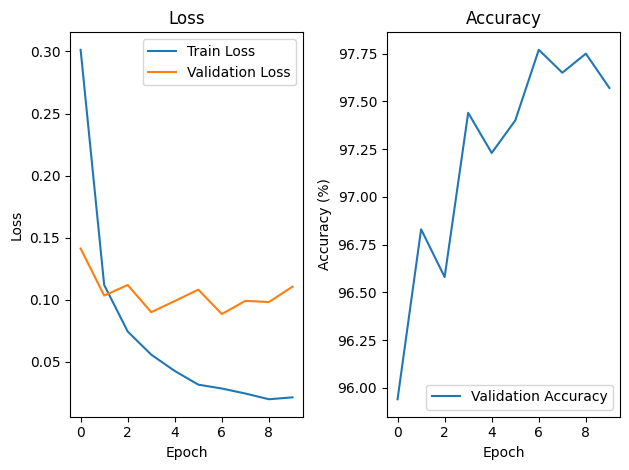

In [32]:
plot_learning_curves(**results)

In [33]:
def test_performance(model, test_loader):
    model.eval()

    correct = 0
    total = 0
    running_test_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.inference_mode():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            test_logits = model(X_batch)
            test_loss = loss_fn(test_logits, y_batch)

            running_test_loss += test_loss.item()
            test_preds = torch.argmax(test_logits, dim=1)

            all_preds.extend(test_preds.tolist())
            all_labels.extend(y_batch.tolist())

            correct += torch.eq(test_preds, y_batch).sum().item()
            total += y_batch.size(0)

    acc = (correct / total) * 100
    avg_test_loss = running_test_loss / total

    print(f"Average Test Loss: {avg_test_loss}")
    print(f"Accuracy: {acc}%\n")

    conf = confusion_matrix(all_labels, all_preds)
    metrics = classification_report(all_labels, all_preds)

    print(conf)
    print(metrics)

    disp = ConfusionMatrixDisplay(confusion_matrix=conf)
    disp.plot()
    plt.show()

Average Test Loss: 0.001436380598077085
Accuracy: 97.7%

[[ 968    1    2    0    0    3    2    1    2    1]
 [   2 1119    4    1    0    2    4    0    3    0]
 [   2    0 1018    2    1    0    5    1    3    0]
 [   1    1   10  979    1    8    0    4    5    1]
 [   0    0    2    0  956    4    9    2    1    8]
 [   3    0    0    6    0  875    1    1    4    2]
 [   3    1    1    0    3    5  943    0    2    0]
 [   2    5   19    1    0    1    0  995    2    3]
 [   3    0    7    4    1    7    5    1  942    4]
 [   3    3    1    4   10    6    0    6    1  975]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.99      0.97      1032
           3       0.98      0.97      0.98      1010
           4       0.98      0.97      0.98       982
           5       0.96      0.98      0.97       892
           6       0.97      0.98

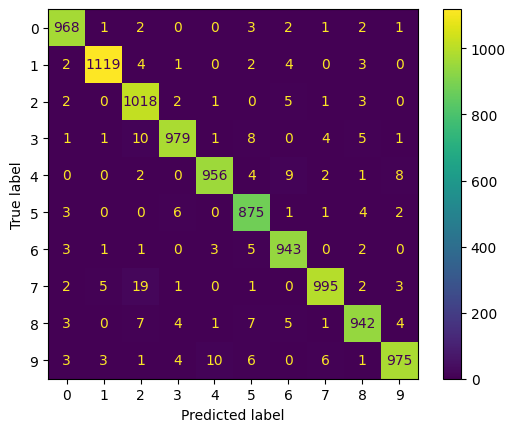

In [36]:
model_0.load_state_dict(best_model_state)
test_performance(model_0, test_loader)

# Implementing MNIST Classification in a 2D-CNN Model

In [37]:
class ConvolutionalModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=8, out_channels=8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Flatten(),
            nn.Linear(in_features=8*7*7, out_features=128),
            nn.ReLU(),

            nn.Linear(in_features=128, out_features=10)
        )

    def forward(self, x):
        x = x.view(-1, 1, 28, 28)
        return self.network(x)


In [38]:
model_cnn = ConvolutionalModel()

In [39]:
all_preds = []

for batch_index, (images, labels) in enumerate(iter(val_loader)):
    logits = model_cnn(images)
    preds = torch.argmax(logits, dim=1)
    all_preds.extend(preds.tolist())

print(f"Processed all images. Total predictions made: {len(all_preds)}")
print(all_preds[:10])

Processed all images. Total predictions made: 10000
[8, 8, 8, 8, 8, 8, 8, 8, 8, 8]


In [44]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_cnn.parameters(), lr=0.001)

results, best_model_state, best_val_loss = train_model(
    model_cnn,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=10,
    device="cpu"
)

# def train_model(
#         model,
#         train_loader,
#         val_loader,
#         loss_fn,
#         optimizer,
#         epochs=10,
#         device="cpu"
# ):

--> Saved current state. Val Loss: 0.053415698862959375
Epoch 1/10 | Train Loss: 0.0221 | Validation Loss: 0.0534 | Validation Acc: 98.74%
--> Saved current state. Val Loss: 0.05151867379833333
Epoch 2/10 | Train Loss: 0.0189 | Validation Loss: 0.0515 | Validation Acc: 98.64%
Epoch 3/10 | Train Loss: 0.0174 | Validation Loss: 0.0522 | Validation Acc: 98.68%
Epoch 4/10 | Train Loss: 0.0150 | Validation Loss: 0.0613 | Validation Acc: 98.48%
Epoch 5/10 | Train Loss: 0.0140 | Validation Loss: 0.0551 | Validation Acc: 98.69%
Epoch 6/10 | Train Loss: 0.0111 | Validation Loss: 0.0609 | Validation Acc: 98.58%
Epoch 7/10 | Train Loss: 0.0120 | Validation Loss: 0.0543 | Validation Acc: 98.68%
Epoch 8/10 | Train Loss: 0.0110 | Validation Loss: 0.0584 | Validation Acc: 98.76%
Epoch 9/10 | Train Loss: 0.0095 | Validation Loss: 0.0592 | Validation Acc: 98.80%
Epoch 10/10 | Train Loss: 0.0071 | Validation Loss: 0.0743 | Validation Acc: 98.52%


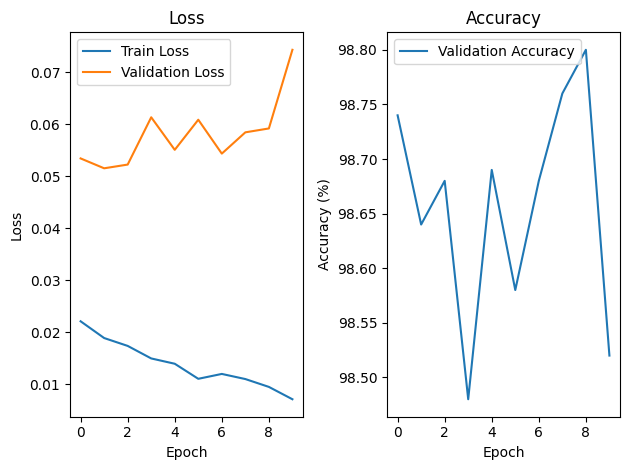

In [45]:
plot_learning_curves(**results)

Average Test Loss: 0.0009259905962877383
Accuracy: 98.56%

[[ 975    0    0    0    1    1    1    2    0    0]
 [   0 1132    0    1    0    0    1    1    0    0]
 [   2    4 1004    5    1    0    2   12    2    0]
 [   1    0    1 1005    0    2    0    0    1    0]
 [   0    1    0    0  978    0    0    0    0    3]
 [   2    0    0   11    0  878    1    0    0    0]
 [   5    2    1    0    2    1  946    0    1    0]
 [   0    8    1    0    0    0    0 1018    0    1]
 [   6    2    1    1    3    3    0    3  949    6]
 [   1    5    0    1   15    1    0   13    2  971]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.98      1.00      0.99      1135
           2       1.00      0.97      0.98      1032
           3       0.98      1.00      0.99      1010
           4       0.98      1.00      0.99       982
           5       0.99      0.98      0.99       892
           6       0.99      0.

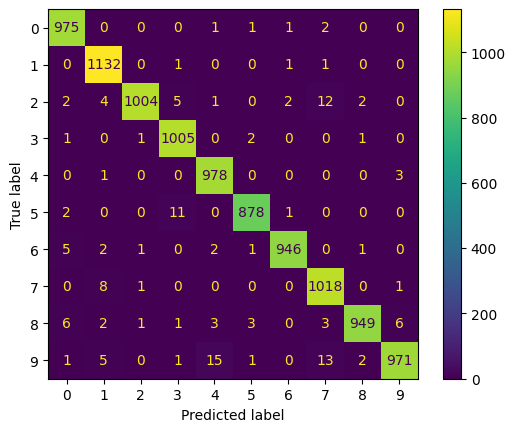

In [46]:
test_performance(model_cnn, test_loader)

Average Test Loss: 0.000602183157595573
Accuracy: 98.72999999999999%

[[ 975    0    0    0    1    1    0    1    2    0]
 [   0 1131    0    1    0    0    2    1    0    0]
 [   3    0 1014    4    1    0    0    5    5    0]
 [   1    0    1  999    0    4    0    1    1    3]
 [   1    0    0    0  971    0    0    0    1    9]
 [   1    0    0    6    0  882    2    0    0    1]
 [   8    2    0    0    2    7  938    0    1    0]
 [   0    4    4    0    0    0    0 1012    0    8]
 [   4    1    1    2    1    3    0    0  960    2]
 [   1    2    0    1    7    3    1    1    2  991]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.98      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.98       892
           6       0

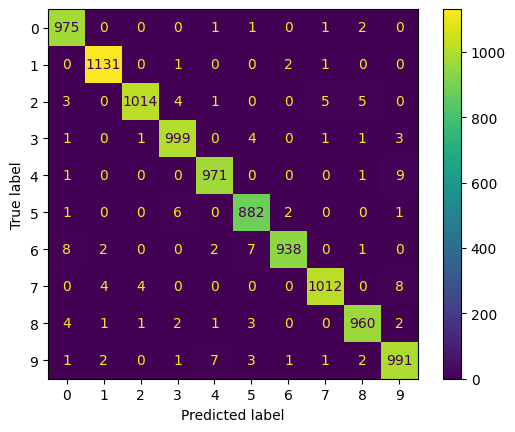

In [47]:
model_cnn.load_state_dict(best_model_state)
test_performance(model_cnn, test_loader)

### Advanced CNN Architecture (with greater width, BatchNorm, Dropout)
Design CNNs in this way:
* Start shallow and wide (channels=1 to 3, frame=28x28 or 32x32)
* End deep and narrow (channels=16/32/64, frame=7x7 or 4x4)

In [48]:
class AdvancedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Flatten(),

            nn.Linear(7*7*32, 128),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.network(x.view(-1, 1, 28, 28))

### Advanced CNN 1: Adam Optimizer, lr=0.0003

In [49]:
model_adv_cnn = AdvancedCNN()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_adv_cnn.parameters(), lr=0.0003)

results, best_model_state, best_val_loss = train_model(
    model_adv_cnn,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=30,
    device="cpu"
)

--> Saved current state. Val Loss: 0.07319392831284244
Epoch 1/30 | Train Loss: 0.2416 | Validation Loss: 0.0732 | Validation Acc: 97.82%
--> Saved current state. Val Loss: 0.052362579695144844
Epoch 2/30 | Train Loss: 0.0712 | Validation Loss: 0.0524 | Validation Acc: 98.52%
--> Saved current state. Val Loss: 0.04514137466933436
Epoch 3/30 | Train Loss: 0.0518 | Validation Loss: 0.0451 | Validation Acc: 98.68%
--> Saved current state. Val Loss: 0.039058370351832905
Epoch 4/30 | Train Loss: 0.0406 | Validation Loss: 0.0391 | Validation Acc: 98.89%
--> Saved current state. Val Loss: 0.038010746299565
Epoch 5/30 | Train Loss: 0.0342 | Validation Loss: 0.0380 | Validation Acc: 98.90%
Epoch 6/30 | Train Loss: 0.0278 | Validation Loss: 0.0386 | Validation Acc: 98.89%
Epoch 7/30 | Train Loss: 0.0256 | Validation Loss: 0.0410 | Validation Acc: 98.85%
Epoch 8/30 | Train Loss: 0.0205 | Validation Loss: 0.0398 | Validation Acc: 98.91%
--> Saved current state. Val Loss: 0.03553740694046697
Epoch 

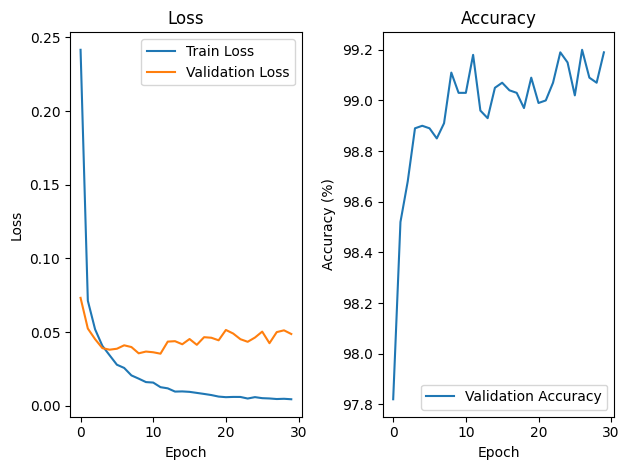

In [50]:
plot_learning_curves(**results)

Average Test Loss: 0.0006297727902432371
Accuracy: 99.00999999999999%

[[ 977    0    1    0    0    0    1    1    0    0]
 [   0 1130    0    2    0    0    2    0    1    0]
 [   1    4 1020    0    1    0    0    6    0    0]
 [   0    0    3 1002    0    4    0    0    1    0]
 [   0    0    0    0  979    0    1    0    1    1]
 [   1    0    1    5    0  884    1    0    0    0]
 [   4    2    1    0    1    1  949    0    0    0]
 [   0    3    7    0    0    0    0 1016    0    2]
 [   1    0    3    1    0    1    4    2  960    2]
 [   2    1    1    4    9    4    0    3    1  984]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.98      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       

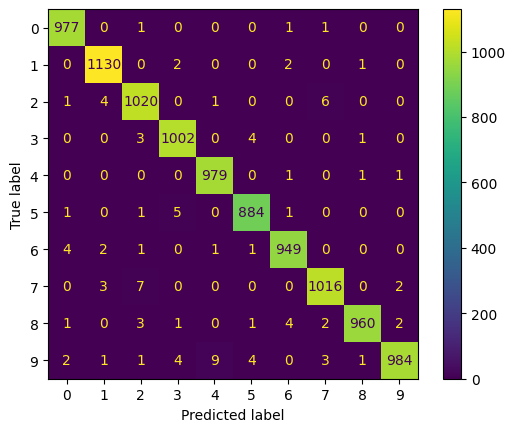

In [51]:
test_performance(model_adv_cnn, test_loader)

Average Test Loss: 0.0004933481884305366
Accuracy: 99.00999999999999%

[[ 979    0    0    0    0    0    0    1    0    0]
 [   0 1130    1    1    0    0    1    0    2    0]
 [   2    0 1024    1    1    0    0    4    0    0]
 [   0    0    1 1006    0    2    0    0    1    0]
 [   0    0    0    0  975    0    0    0    2    5]
 [   1    0    0    7    0  882    1    0    0    1]
 [   8    2    1    0    1    3  943    0    0    0]
 [   0    4    5    1    0    0    0 1015    0    3]
 [   3    0    2    2    0    4    0    2  959    2]
 [   2    0    0    3    5    5    0    4    2  988]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       

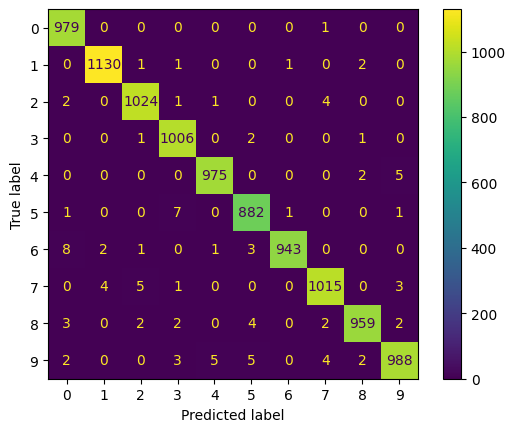

In [52]:
model_adv_cnn.load_state_dict(best_model_state)
test_performance(model_adv_cnn, test_loader)

### Advanced CNN 2: AdamW Optimizer (lr=0.0003, weight_decay=1e-4)

In [53]:
model_adamw = AdvancedCNN()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(params=model_adamw.parameters(), lr=0.0003, weight_decay=1e-4)

results, best_model_state, best_val_loss = train_model(
    model_adamw,
    train_loader,
    val_loader,
    loss_fn,
    optimizer,
    epochs=20,
    device="cpu"
)

--> Saved current state. Val Loss: 0.07981868581193838
Epoch 1/20 | Train Loss: 0.2518 | Validation Loss: 0.0798 | Validation Acc: 97.63%
--> Saved current state. Val Loss: 0.0560459234739897
Epoch 2/20 | Train Loss: 0.0777 | Validation Loss: 0.0560 | Validation Acc: 98.41%
--> Saved current state. Val Loss: 0.05477755865865168
Epoch 3/20 | Train Loss: 0.0565 | Validation Loss: 0.0548 | Validation Acc: 98.39%
--> Saved current state. Val Loss: 0.04715690877923303
Epoch 4/20 | Train Loss: 0.0449 | Validation Loss: 0.0472 | Validation Acc: 98.64%
--> Saved current state. Val Loss: 0.04452146379985983
Epoch 5/20 | Train Loss: 0.0377 | Validation Loss: 0.0445 | Validation Acc: 98.68%
Epoch 6/20 | Train Loss: 0.0309 | Validation Loss: 0.0458 | Validation Acc: 98.67%
--> Saved current state. Val Loss: 0.041024936063535467
Epoch 7/20 | Train Loss: 0.0269 | Validation Loss: 0.0410 | Validation Acc: 98.89%
--> Saved current state. Val Loss: 0.03766794282046538
Epoch 8/20 | Train Loss: 0.0243 | 

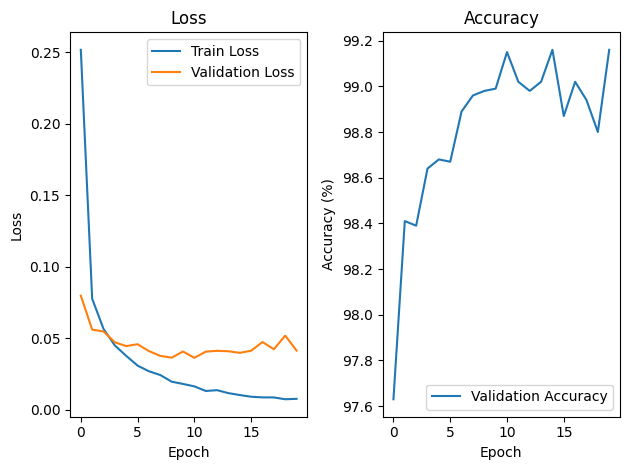

In [54]:
plot_learning_curves(**results)

Average Test Loss: 0.00052115138299705
Accuracy: 98.98%

[[ 977    0    1    0    0    0    1    1    0    0]
 [   0 1133    0    0    0    0    1    1    0    0]
 [   1    0 1027    0    0    0    0    4    0    0]
 [   0    1    1 1006    0    1    0    0    1    0]
 [   0    0    0    0  972    0    3    1    1    5]
 [   2    0    1    8    0  874    6    1    0    0]
 [   4    3    1    0    1    1  947    0    1    0]
 [   0    2    8    1    0    1    0 1015    1    0]
 [   3    0    1    1    0    0    2    1  966    0]
 [   3    1    0    3    9    3    0    5    4  981]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.98      0.99       892
           6       0.99      0.99

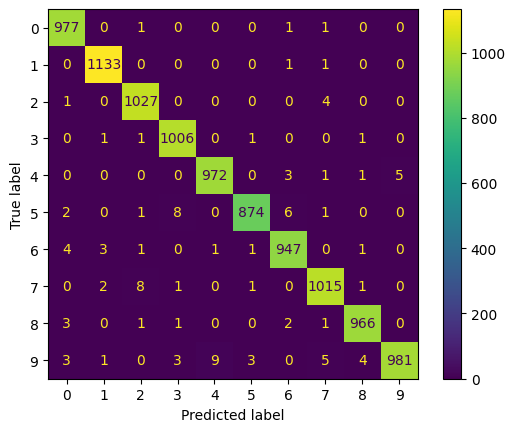

In [55]:
test_performance(model_adamw, test_loader)

Average Test Loss: 0.00047500066812790467
Accuracy: 99.06%

[[ 976    0    1    1    0    1    1    0    0    0]
 [   0 1132    1    1    0    0    0    1    0    0]
 [   1    0 1027    0    0    0    0    4    0    0]
 [   0    0    1 1006    0    2    0    1    0    0]
 [   0    0    0    0  975    0    1    1    3    2]
 [   2    0    1    5    0  882    2    0    0    0]
 [   5    3    2    0    1    3  943    0    1    0]
 [   0    0    6    0    0    0    0 1019    1    2]
 [   2    0    1    1    0    1    0    0  968    1]
 [   1    2    0    1    6    7    0    7    7  978]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       1.00      0

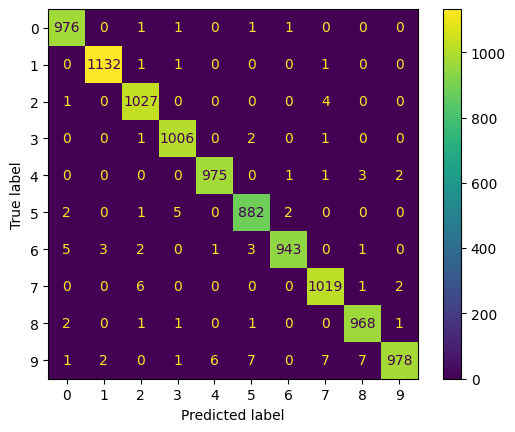

In [56]:
model_adamw.load_state_dict(best_model_state)
test_performance(model_adamw, test_loader)

### Advanced CNN 3: SDG with Momentum Optimizer (momentum=0.9)

In [58]:
model_sdg = AdvancedCNN()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_sdg.parameters(), lr=0.01, momentum=0.9)

results, best_model_state, best_val_loss = train_model(
    model_sdg,
    train_loader,
    val_loader,
    loss_fn,
    optimizer,
    epochs=20,
    device="cpu"
)

--> Saved current state. Val Loss: 0.06401238782972002
Epoch 1/20 | Train Loss: 0.1795 | Validation Loss: 0.0640 | Validation Acc: 98.14%
--> Saved current state. Val Loss: 0.06159198838197122
Epoch 2/20 | Train Loss: 0.0641 | Validation Loss: 0.0616 | Validation Acc: 98.18%
--> Saved current state. Val Loss: 0.042778269058556126
Epoch 3/20 | Train Loss: 0.0502 | Validation Loss: 0.0428 | Validation Acc: 98.77%
Epoch 4/20 | Train Loss: 0.0386 | Validation Loss: 0.0440 | Validation Acc: 98.70%
--> Saved current state. Val Loss: 0.03791157644506022
Epoch 5/20 | Train Loss: 0.0327 | Validation Loss: 0.0379 | Validation Acc: 98.96%
--> Saved current state. Val Loss: 0.03602881310285205
Epoch 6/20 | Train Loss: 0.0271 | Validation Loss: 0.0360 | Validation Acc: 98.91%
Epoch 7/20 | Train Loss: 0.0240 | Validation Loss: 0.0400 | Validation Acc: 98.86%
--> Saved current state. Val Loss: 0.03508617491743106
Epoch 8/20 | Train Loss: 0.0206 | Validation Loss: 0.0351 | Validation Acc: 99.14%
Epoch

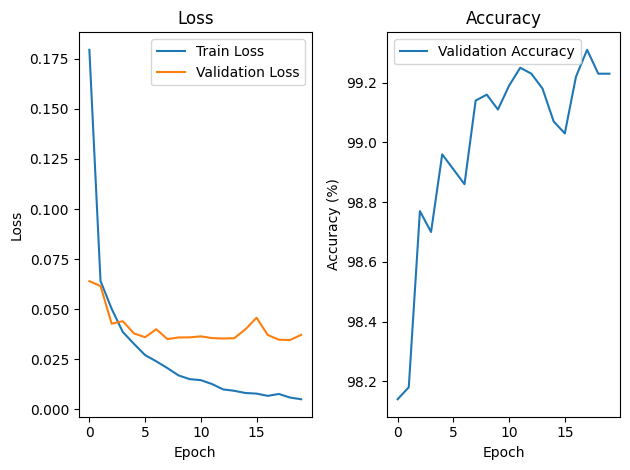

In [59]:
plot_learning_curves(**results)

Average Test Loss: 0.0004582042849560594
Accuracy: 99.31%

[[ 978    0    0    0    0    0    1    1    0    0]
 [   0 1134    0    0    0    0    0    1    0    0]
 [   1    0 1027    0    0    0    0    4    0    0]
 [   0    0    1 1006    0    3    0    0    0    0]
 [   0    1    0    0  974    0    1    0    1    5]
 [   1    0    0    3    0  887    1    0    0    0]
 [   1    1    1    0    1    2  952    0    0    0]
 [   0    2    6    0    0    0    0 1018    0    2]
 [   2    0    2    0    0    0    0    1  968    1]
 [   1    2    1    2    5    6    0    4    1  987]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       0.99      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       1.00      1.00      1.00      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.

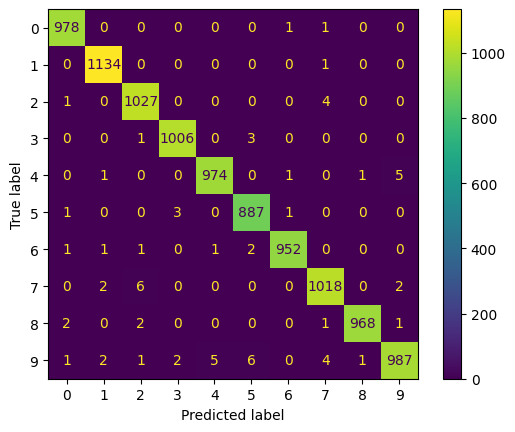

In [60]:
test_performance(model_sdg, test_loader)

Average Test Loss: 0.00045879026807351693
Accuracy: 99.22999999999999%

[[ 978    0    0    0    0    0    1    1    0    0]
 [   0 1130    1    1    0    0    1    2    0    0]
 [   1    0 1026    0    1    0    0    4    0    0]
 [   0    0    0 1007    0    3    0    0    0    0]
 [   0    0    0    0  978    0    1    0    1    2]
 [   1    0    0    3    0  887    1    0    0    0]
 [   3    1    1    0    1    2  949    0    1    0]
 [   0    2    5    0    0    0    0 1020    0    1]
 [   2    0    2    2    0    1    0    1  965    1]
 [   2    2    0    1    5    6    0    7    3  983]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      1.00      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6      

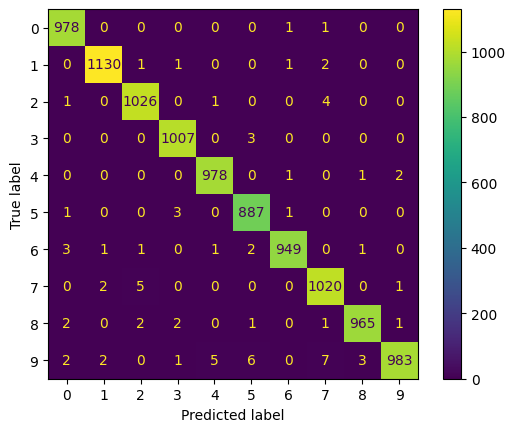

In [61]:
model_sdg.load_state_dict(best_model_state)
test_performance(model_sdg, test_loader)